<a href="https://colab.research.google.com/github/karunachaudhary2112/CodeAlpha_ProjectName/blob/main/task_02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          Name   Age     Sex  Pclass    Fare  Survived
0  Passenger_0  37.0  female       1   47.07         1
1  Passenger_1  28.1  female       3   35.49         0
2  Passenger_2   NaN    male       3   75.51         0
3  Passenger_3  51.3  female       1   36.30         1
4  Passenger_4  26.7    male       3  121.24         0
                 Name         Age   Sex      Pclass        Fare    Survived
count             891  811.000000   891  891.000000  871.000000  891.000000
unique            891         NaN     2         NaN         NaN         NaN
top     Passenger_890         NaN  male         NaN         NaN         NaN
freq                1         NaN   565         NaN         NaN         NaN
mean              NaN   30.535265   NaN    2.328844   52.595178    0.483726
std               NaN   13.604660   NaN    0.828325   30.273510    0.500016
min               NaN    0.300000   NaN    1.000000   10.160000    0.000000
25%               NaN   20.950000   NaN    2.000000   32.80500

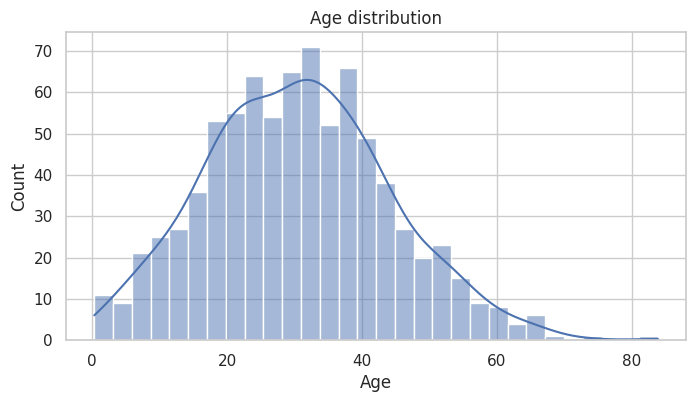

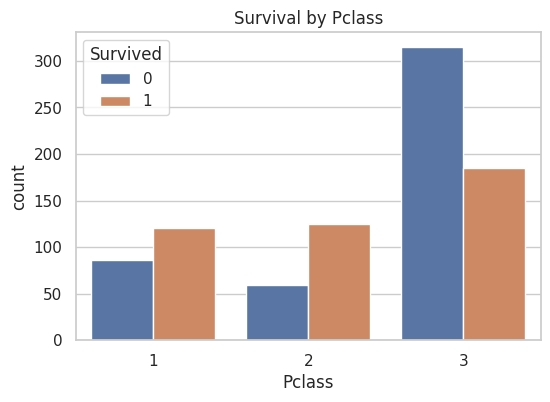

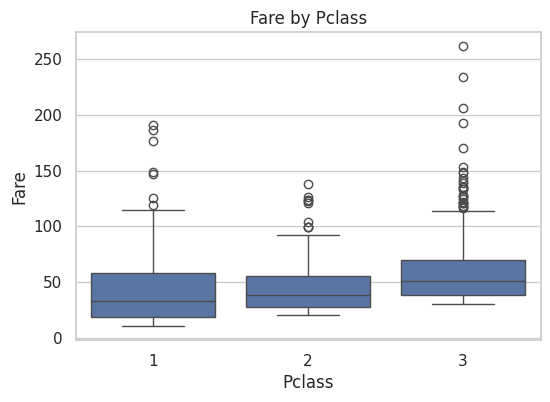

              Name   Age     Sex  Pclass    Fare  Survived
367  Passenger_367  30.2  female       3  206.16         0
461  Passenger_461  30.5    male       1  176.85         1
468  Passenger_468  22.6    male       3  234.17         1
473  Passenger_473  49.1  female       1  191.32         1
497  Passenger_497  27.3  female       3  170.27         1
saved file: demo_titanic_like.csv


In [1]:
# This cell creates a sample CSV (Titanic-like), loads it, and performs EDA: head, describe, missing values, basic plots.
# It saves the CSV to disk for download.
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample dataset similar to Titanic for EDA demonstration
np.random.seed(42)
N = 891
names = ["Passenger_" + str(i) for i in range(N)]
ages = np.random.normal(30, 14, N).round(1)
ages[ages < 0] = np.abs(ages[ages < 0])
sex = np.random.choice(["male","female"], N, p=[0.64,0.36])
pclass = np.random.choice([1,2,3], N, p=[0.24,0.2,0.56])
fare = (np.random.exponential(1.0, N) * 30 + pclass * 10).round(2)
survived = np.where((sex=="female") & (pclass !=3), 1, np.random.binomial(1, 0.38, N))

# Introduce some missing values
ages[np.random.choice(N, 80, replace=False)] = np.nan
fare[np.random.choice(N, 20, replace=False)] = np.nan

df_demo = pd.DataFrame({
    'Name': names,
    'Age': ages,
    'Sex': sex,
    'Pclass': pclass,
    'Fare': fare,
    'Survived': survived
})

# Save CSV
csv_filename = 'demo_titanic_like.csv'
df_demo.to_csv(csv_filename, index=False)

# EDA outputs
print(df_demo.head())
print(df_demo.describe(include='all'))

# Missing values
missing = df_demo.isnull().sum()
print(missing)

# Simple visualizations
sns.set(style='whitegrid')
plt.figure(figsize=(8,4))
sns.histplot(df_demo['Age'], bins=30, kde=True)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df_demo)
plt.title('Survival by Pclass')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Pclass', y='Fare', data=df_demo)
plt.title('Fare by Pclass')
plt.show()

# Simple anomaly detection: fares extremely high
high_fare = df_demo[df_demo['Fare'] > df_demo['Fare'].quantile(0.99)]
print(high_fare.head())

print('saved file: ' + csv_filename)